# Defining Parameters and utility function
## 1. Economic parameters
## 2. Numeric parameters
## 3. Constructing Grid Bounds
## 

In [218]:
using Plots
using Printf
using Statistics

In [219]:
Base.@kwdef struct EconomicParameters
    α::Float64 = 0.3    # capital share
    β::Float64 = 0.96   # subjective discount factor
    δ::Float64 = 1.0    # capital depreciation rate
    γ::Float64 = 1.0    # Risk Aversion rate
end 

Base.@kwdef struct NumericalParameters
    nk::Int = 200             # number of points on the capital grid, N
    kmin_rel::Float64 = 0.1   # lower grid bound, relative to k*
    kmax_rel::Float64 = 2.0   # upper grid bound, relative to k*
    spacing::Symbol = :linear # :linear or :log
    crit::Float64 = 1e-6      # convergence tolerance, ε
    maxiter::Int = 5000       # iteration cap, the safety net    
end

par = EconomicParameters()
mpar = NumericalParameters()
println("Economic parameters:  ", par)
println("Numerical parameters: ", mpar)

Economic parameters:  EconomicParameters(0.3, 0.96, 1.0, 1.0)
Numerical parameters: NumericalParameters(200, 0.1, 2.0, :linear, 1.0e-6, 5000)


In [220]:
# Utility function
function util(c, p::EconomicParameters)
    if p.γ == 1.0
        return log(c)
    else
        return (c^(1 - p.γ) - 1) / (1 - p.γ)
    end
end

util (generic function with 1 method)

In [221]:
# Computing closed-form benchmark for the baseline problem
F_star = par.α / (1 - par.α * par.β)
E_star = (log(1 - par.α * par.β) + par.β * F_star * log(par.α * par.β)) / (1 - par.β)
v_true = E_star .+ F_star .* log.(gri.k)
kprime_true = par.α * par.β .* gri.k .^ par.α
@printf("E = %.4f, F = %.4f\n", E_star, F_star)

E = -21.0797, F = 0.4213


# Question 2.1

In [222]:
# Question 2.1.b

#Grid construction 
function construct_grids(par,mpar; verbose = true)
    # Computing bounds and range of grid
    kstar = ((par.α) / ((1 / par.β) - 1 + par.δ))^(1 / (1 - par.α))
    kmin, kmax = mpar.kmin_rel * kstar, mpar.kmax_rel * kstar
    if verbose
        @printf("k* = %.4f, grid bounds %.4f to %.4f\n", kstar, kmin, kmax)
    end 

    # Generating interior grid points
    if mpar.spacing == :linear
        gri = (k = collect(range(kmin, kmax, length = mpar.nk)),)
    else                                         # equidistant in ln k
        gri = (k = exp.(range(log(kmin), log(kmax), length = mpar.nk)),) # equidistant in ln k: the range runs from the log of the lower bound to the log of the upper bound
    end
    if verbose
        @printf("%d points, first spacing %.5f, last spacing %.5f\n", mpar.nk, gri.k[2] - gri.k[1], gri.k[end] - gri.k[end-1])
    end 

    # Constructing actual (k,k') grid as a N x N table
    meshes = (
        k      = [k  for k in gri.k, kP in gri.k],   # k_i in row i, the same in every column
        kprime = [kP for k in gri.k, kP in gri.k],   # k'_j in column j, the same in every row
    )
    size(meshes.k), size(meshes.kprime)
    return gri, meshes
end 

# Reward matrix construction
function compute_reward(par, meshes; verbose = true)
    # Constructing reward matrix U for baseline formulation of problem (Matrix is dependent on delta!)
    Y = meshes.k .^ par.α
    C = meshes.k .^ par.α - meshes.kprime .+ (1 - par.δ) .* meshes.k

    U = fill(-Inf, size(C))
    U[C .> 0] = util.(C[C .> 0], Ref(par))
    if verbose
        println("share of feasible pairs: ", round(count(C .> 0) / length(C), digits = 4))
        println("no NaN in U: ", !any(isnan, U))
    end 
    return U
end 

function solve_vfi(par, mpar; verbose = true, baseline = false)
    if verbose
        @printf("Value function iteration with parameters α = %.3f, β = %.3f, γ = %.3f, δ = %.3f, N = %.0f, crit = %.0e\n", par.α,par.β,par.γ,par.δ,mpar.nk,mpar.crit)
    end
    # import grids and reward matrix
    gri, meshes = construct_grids(par,mpar; verbose = verbose)
    U = compute_reward(par, meshes; verbose = verbose) 
    # initialize grids
    v      = zeros(mpar.nk)                      # line 2: the guess v_0 = 0
    g      = ones(Int, mpar.nk)                  # the policy as grid indices
    distVF = [Inf]                               # distances d_n, one per iteration
    iterVF = 0
    timer = time()
    while distVF[end] > mpar.crit && iterVF < mpar.maxiter          # line 3: keep going while the last distance, distVF[end], exceeds mpar.crit
        M    = U .+ par.β .* v'                              # line 4: U plus β times the row vector v', the dots .+ and .* broadcast it over every row
        vals, idx = findmax(M, dims = 2)         # line 5: maximum along each row ...
        vnew = vec(vals)
        g    = vec(getindex.(idx,2))                           # idx holds a CartesianIndex (i, j) per row: getindex.(idx, 2) picks the column j, vec turns it into a vector
        dd   = maximum(abs.(vnew - v))                              # line 6: the max norm of vnew minus v, maximum(abs.( ... ))
        v    = vnew                              # line 7: update
        iterVF += 1
        push!(distVF, dd)
    end
    time_vfi = time() - timer
    if verbose
        @printf("iterations: %d, final distance: %.3e, time: %.3f s\n", iterVF, distVF[end], time_vfi)
    end

    # validate convergence
    if distVF[end] > mpar.crit
        error("not converged: the iteration cap was hit")
    end

    # Deriving corresponding policy functions
    kprime = gri.k[g]                            # the policy in levels, k_{g_i}
    c = gri.k .^ par.α .+ (1 - par.δ) .* gri.k .- kprime


    if verbose
    # Check for reaching grid bounds
        println("Does the policy function hit the grid bounds?")
        println("policy at the lowest grid point:  ", count(g .== 1), " states")
        println("policy at the highest grid point: ", count(g .== mpar.nk), " states")

        # Check for the Policy and Value error of the VFI
        if baseline
            println("Policy and Value error:")
            @printf("largest policy error: %.2e   (first grid spacing: %.2e)\n", maximum(abs.(kprime .- kprime_true)), gri.k[2] - gri.k[1])
            @printf("largest value error:  %.2e   (certificate β/(1-β) d: %.2e)\n", maximum(abs.(v .- v_true)), par.β / (1 - par.β) * distVF[end])
        end 
        
        # Check for the contraction rate: if should be equal to the discount rate
        println("Contraction Rate of the VFI:")
        @printf("last ratio d_n / d_(n-1): %.4f   (β = %.2f)\n", distVF[end] / distVF[end-1], par.β)
    end 
    
    return g, gri.k, v, kprime, c
end 

test = solve_vfi(par,mpar, baseline = true);

Value function iteration with parameters α = 0.300, β = 0.960, γ = 1.000, δ = 1.000, N = 200, crit = 1e-06
k* = 0.1689, grid bounds 0.0169 to 0.3379
200 points, first spacing 0.00161, last spacing 0.00161
share of feasible pairs: 0.9976
no NaN in U: true
iterations: 337, final distance: 9.792e-07, time: 0.067 s
Does the policy function hit the grid bounds?
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Policy and Value error:
largest policy error: 9.39e-04   (first grid spacing: 1.61e-03)
largest value error:  2.41e-05   (certificate β/(1-β) d: 2.35e-05)
Contraction Rate of the VFI:
last ratio d_n / d_(n-1): 0.9600   (β = 0.96)


In [223]:
# Question 2.1.c and d
# Closed form solution for baseline problem
kprime_closed = par.α .* par.β .* gri.k .^ par.α
kprime_next = par.α .* par.β .* kprime_closed .^ par.α
c_today = gri.k .^ par.α .+ (1 - par.δ) .* gri.k .- kprime_closed
c_tomorrow = kprime_closed  .^ par.α .+ (1 - par.δ) .* kprime_closed  .- kprime_next

euler_error = 1 .- (par.β.*(par.α .* kprime_closed .^(par.α -1) .+ 1 .- par.δ)).^(-(1 ./ par.γ)) .* (c_next ./ c_tomorrow)
@printf("Value function iteration with parameters α = %.3f, β = %.3f, γ = %.3f, δ = %.3f, N = %.0f, crit = %.0e\n", par.α,par.β,par.γ,par.δ,mpar.nk,mpar.crit)
@printf("largest Euler equation error: %.2e\n", maximum(abs.(euler_error)))

# Generalized function 
function euler_eq_error(par, mpar)
    g, k_grid = solve_vfi(par, mpar; verbose = false)
    # current capital
    k_today = k_grid
    # tomorrow's capital
    k_next = k_grid[g]
    # current consumption
    c = k_today .^ par.α .+ (1 - par.δ) .* k_today .- k_next
    # tomorrow's consumption
    c_next = c[g]
    # Euler error
    euler_error = 1 .- (par.β.*(par.α .* k_next .^(par.α -1) .+ 1 .- par.δ)).^(-(1 ./ par.γ)) .* (c_next ./ c)
    max_error, idx = findmax(abs.(euler_error))
    k_at_max = k_grid[idx]

    @printf("maximum absolute Euler error: %.3e at index %d, k = %.5f\n", max_error, idx, k_at_max)
    return euler_error
end

@printf("Value function iteration with parameters α = %.3f, β = %.3f, γ = %.3f, δ = %.3f, N = %.0f, crit = %.0e\n", par.α,par.β,par.γ,par.δ,mpar.nk,mpar.crit)
euler_error_log = euler_eq_error(par);


Value function iteration with parameters α = 0.300, β = 0.960, γ = 1.000, δ = 1.000, N = 200, crit = 1e-06
largest Euler equation error: 3.83e-01
Value function iteration with parameters α = 0.300, β = 0.960, γ = 1.000, δ = 1.000, N = 200, crit = 1e-06
maximum absolute Euler error: 1.170e-02 at index 2, k = 0.01851


maximum absolute Euler error: 4.563e-02 at index 1, k = 0.29208
Mean of log10 of Euler equation error: -1.114


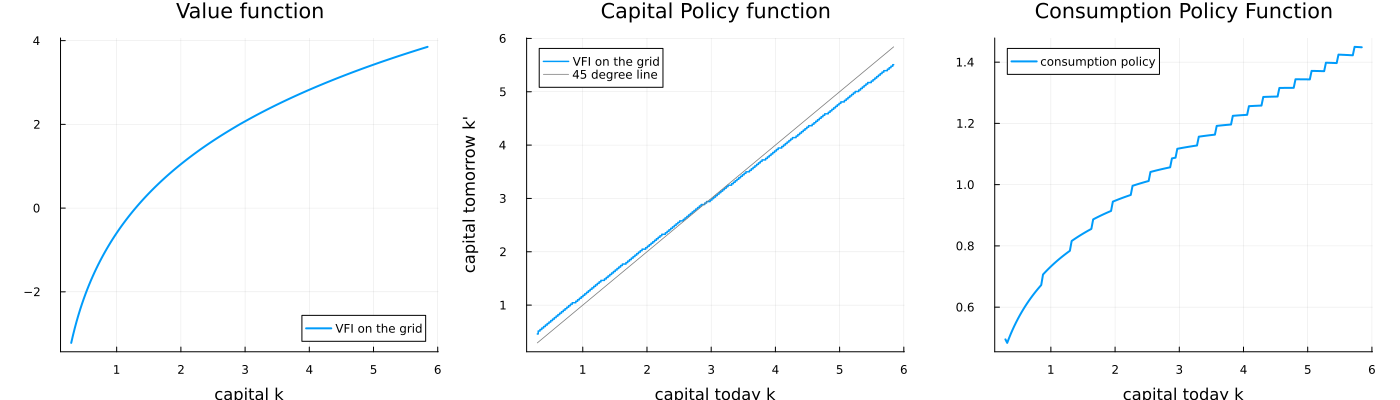

In [224]:
# Question 2.1.E
par = EconomicParameters(γ = 2.0, δ = 0.1)
euler_error_CRRA = euler_eq_error(par)
mean_euler_error_CRR = mean(log10.(abs.(euler_error)))
@printf("Mean of log10 of Euler equation error: %.3f\n", mean_euler_error_CRR)
policy_idx, k_grid, value, policy_capital, consumption = solve_vfi(par, mpar, verbose = false)

p1 = plot(k_grid, value, linewidth = 2, label = "VFI on the grid", legend = :bottomright,
          xlabel = "capital k", title = "Value function")
p2 = plot(k_grid, policy_capital, seriestype = :stepmid, linewidth = 1.5, label = "VFI on the grid", legend = :topleft,
          xlabel = "capital today k", ylabel = "capital tomorrow k'", title = "Capital Policy function")
plot!(p2, k_grid, k_grid, color = :gray, linewidth = 0.8, label = "45 degree line")

p3 = plot(k_grid, consumption, linewidth = 2, label = "consumption policy",
          xlabel = "capital today k", title = "Consumption Policy Function")

plot(p1, p2, p3, layout = (1, 3), size = (1400, 400), margin = 5Plots.mm)

# Question 2.2

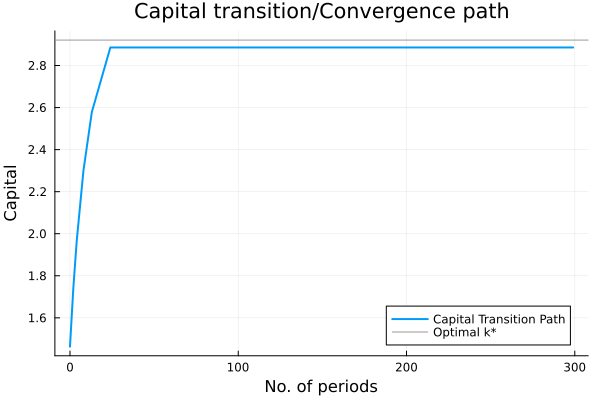

In [225]:
# Question 2.2.a

function transition_path(par, mpar)
    # Compute k* and identify nearest grid point
    k_optimal = ((par.α) / ((1 / par.β) - 1 + par.δ))^(1 / (1 - par.α))
    g, k_grid, value, policy_capital, consumption = solve_vfi(par, mpar, verbose = false)
    dist_k0_grid = k_grid .- (0.5 * k_optimal)
    idx = argmin(abs.(dist_k0_grid))
    k_0 = k_grid[idx]

    # Initialize Vectors to store transition dynamics
    idx_path = Vector{Int}(undef, 300)
    k_path   = Vector{Float64}(undef, 300)

    idx_path[1] = idx
    k_path[1] = k_grid[idx]

    # Transition dynamics loop
    for t in (1:299)
        idx_path[t+1] = g[idx_path[t]]
        k_path[t+1] = k_grid[idx_path[t+1]]
    end 

    # Plot Transition path
    t_path = (0:299)

    p1 = plot(t_path, k_path, linewidth = 2, label = "Capital Transition Path", legend = :bottomright,
            xlabel = "No. of periods", ylabel = "Capital", title = "Capital transition/Convergence path")
        hline!(p1, [k_optimal], color = :gray, linewidth = 0.8, label = "Optimal k*")

    display(p1)  
end

Baseline = transition_path(par, mpar)

Value function iteration with parameters α = 0.300, β = 0.960, γ = 2.000, δ = 0.100, N = 50, crit = 1e-06
k* = 2.9208, grid bounds 0.2921 to 5.8416
50 points, first spacing 0.11326, last spacing 0.11326
share of feasible pairs: 0.662
no NaN in U: true
iterations: 230, final distance: 9.667e-07, time: 0.005 s
Does the policy function hit the grid bounds?
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Contraction Rate of the VFI:
last ratio d_n / d_(n-1): 0.9600   (β = 0.96)
maximum absolute Euler error: 1.653e-01 at index 7, k = 0.97162
Value function iteration with parameters α = 0.300, β = 0.960, γ = 2.000, δ = 0.100, N = 200, crit = 1e-06
k* = 2.9208, grid bounds 0.2921 to 5.8416
200 points, first spacing 0.02789, last spacing 0.02789
share of feasible pairs: 0.6664
no NaN in U: true
iterations: 226, final distance: 9.804e-07, time: 0.040 s
Does the policy function hit the grid bounds?
policy at the lowest grid point:  0 states
policy at the hig

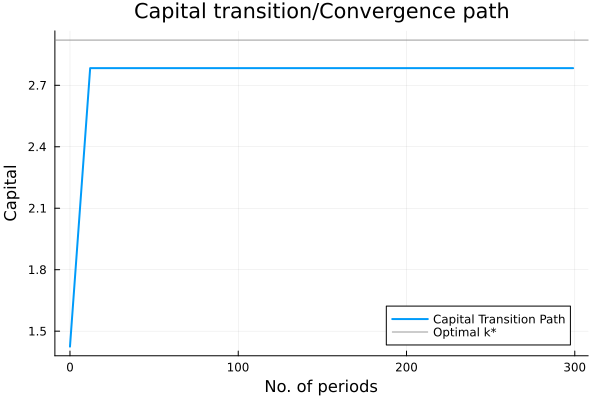

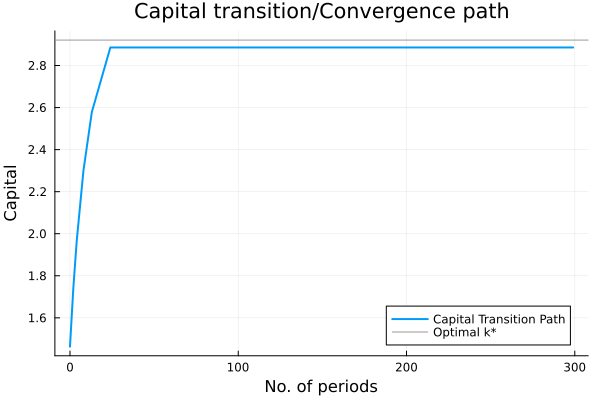

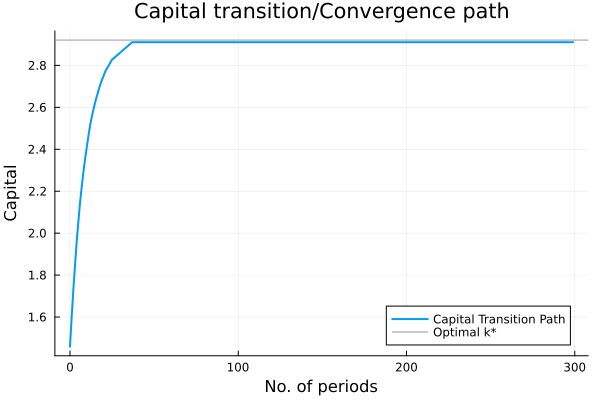

In [226]:
# Question 2.2.b

for N in [50, 200, 800]
    mpar = NumericalParameters(nk = N)

    vfi_N = solve_vfi(par, mpar)
    euler_error_N = euler_eq_error(par, mpar)
    plot_N = transition_path(par, mpar)
end


Value function iteration with parameters α = 0.300, β = 0.960, γ = 1.000, δ = 1.000, N = 800, crit = 1e-06
k* = 0.1689, grid bounds 0.0169 to 0.3379
800 points, first spacing 0.00040, last spacing 0.00040
share of feasible pairs: 0.9979
no NaN in U: true
iterations: 337, final distance: 9.792e-07, time: 1.674 s
Does the policy function hit the grid bounds?
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Contraction Rate of the VFI:
last ratio d_n / d_(n-1): 0.9600   (β = 0.96)
maximum absolute Euler error: 3.234e-03 at index 19, k = 0.02412
Value function iteration with parameters α = 0.300, β = 0.960, γ = 2.000, δ = 1.000, N = 800, crit = 1e-06
k* = 0.1689, grid bounds 0.0169 to 0.3379
800 points, first spacing 0.00040, last spacing 0.00040
share of feasible pairs: 0.9979
no NaN in U: true
iterations: 349, final distance: 9.638e-07, time: 1.419 s
Does the policy function hit the grid bounds?
policy at the lowest grid point:  0 states
policy at the

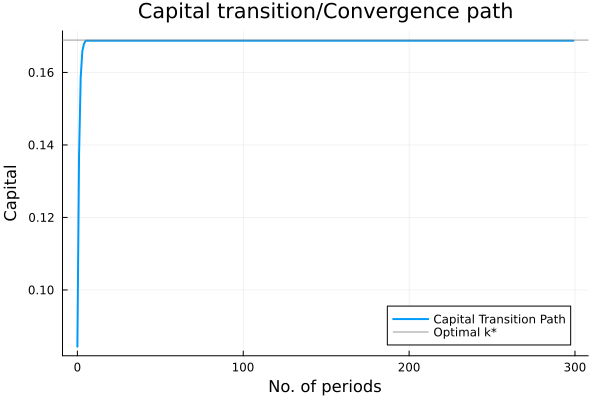

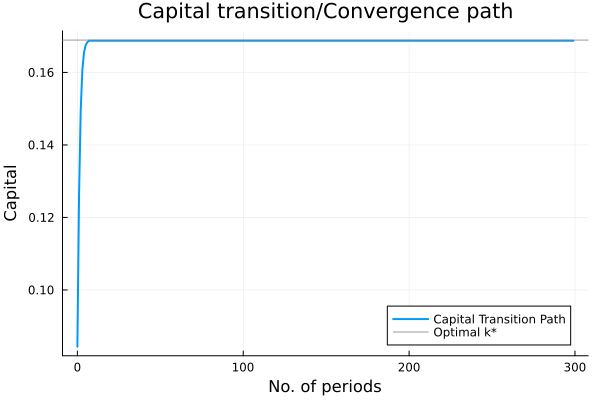

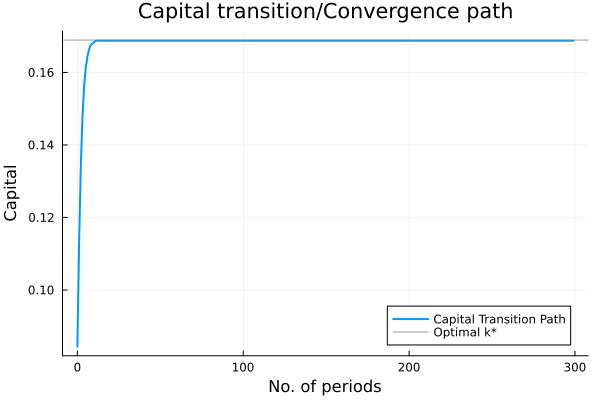

In [227]:
# Question 2.2.d_
mpar = NumericalParameters(nk = 800)

for gamma in [1.0, 2.0, 5.0]
    par = EconomicParameters(γ = gamma)

    vfi_N = solve_vfi(par, mpar, baseline = false)
    euler_error_N = euler_eq_error(par, mpar)
    plot_N = transition_path(par, mpar)
end
